# Pympact development
## How many asteroids are out there?

In [1]:
import multineas as neas
from multineas import pympact as pm
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import os
data_dir = f"{pm.data_dir}/"
get_ipython = pm.get_ipython()
%load_ext autoreload
%autoreload 2

Welcome to MultiNEAs v0.3.5


## Get latest orbit of an asteroid

In [5]:
obj_id = '2024YR4'
#obj_id = 'Apophis'
object_dir = f"{pm.objects_dir}/{obj_id}"
object_file = f"{pm.objects_dir}/object-{obj_id}.json"
object_info = dict()
if not os.path.isdir(object_dir):
    os.system(f"mkdir -p {object_dir}")
    os.system(f"mkdir -p {object_dir}/sim")

orbit_json,jd_0,mus,covmat = pm.get_latest_orbit(id=obj_id,verbose=True)

present_orbit = np.vstack(([jd_0]+[0]*(len(mus)-1),mus,covmat))
orbit_id = orbit_json['object']['orbit_id']
jd0_suf = f"jd0_{jd_0*100:.0f}"

# Object suffix
obj_suf = f"obj_{obj_id}-orbit_{orbit_id}"

# Save orbital elements
file_orbit = f"{object_dir}/elements-{obj_suf}.csv"
print(f"Saving orbital elements in {file_orbit}")
np.savetxt(file_orbit,present_orbit)

####################################################
# Save orbit information
####################################################
orbit_file = f"{object_dir}/orbit-{obj_suf}.json"
orbit_info = object_info.copy()
orbit_info.update(orbit_json)
orbit_info['jd_0'] = jd_0
orbit_info['jd0_suf'] = jd0_suf
orbit_info['obj_suf'] = obj_suf
orbit_info['orbit_id'] = orbit_id
orbit_info['object_dir'] = object_dir
orbit_info['object_file'] = object_file
orbit_info['orbit_file'] = orbit_file

####################################################
# Save orbit information
####################################################
encounters = ["2032-12-22.59"]
encounter_info = orbit_info.copy()
encounter_info['encounters'] = []
for enc_id,encounter_date in enumerate(encounters):
    encounter = dict()
    encounter['id'] = enc_id
    encounter['date'] = encounter_date
    encounter['dateiso'],encounter['jd'] = pm.convert_date_jd(encounter_date)
    encounter['time_seg'] = (encounter['jd'] - encounter_info['jd_0'])*neas.constants.day
    encounter['jd_suf'] = int(encounter['jd']*100)
    encounter_info['encounters'] += [encounter]

pm.save_json(encounter_info,orbit_file)

Orbit id: 78
Elements epoch (JDTDB): 2461000.5
Extracting covariance matrix...
Extracting element values and its errors...
Element e = 6.6147253e-01 +/- 1.2103000e-06
Element a = 2.5158387e+00 +/- 8.4860000e-06
Element q = 8.5168052e-01 +/- 1.7436000e-07
Element i = 3.4081604e+00 +/- 4.4665000e-06
Element om = 2.7136385e+02 +/- 8.2720000e-06
Element w = 1.3436602e+02 +/- 9.3690000e-06
Element ma = 8.9807427e+01 +/- 4.5791000e-04
Element tp = 2.4606369e+06 +/- 1.4594000e-05
Element per = 1.4575472e+03 +/- 7.3745000e-03
Element n = 2.4699029e-01 +/- 1.2497000e-06
Element ad = 4.1799970e+00 +/- 1.4099000e-05
Order of the downloaded orbital elements: ['e', 'q', 'tp', 'node', 'peri', 'i']
Saving orbital elements in data/objects/2024YR4/elements-obj_2024YR4-orbit_78.csv
Saving object information to data/objects/2024YR4/orbit-obj_2024YR4-orbit_78.json


## Generate orbit elements

In [10]:
orbit = pm.load_json(f"{object_dir}/orbit-{obj_suf}.json")
mus, covmat, cov_label = pm.get_mus_cov(orbit)
sigmas = covmat.diagonal()**0.5

Loading json data from data/objects/2024YR4/orbit-obj_2024YR4-orbit_78.json


In [11]:
# Generate sample
Nast = 1000
sample_elements = np.random.multivariate_normal(mus,covmat,Nast)
sample_elements = (sample_elements - mus)/sigmas

In [12]:
import multimin as mn
mn.show_watermark = False
import matplotlib.pyplot as plt

In [13]:
orbit_info['obj_suf']

'obj_2024YR4-orbit_78'

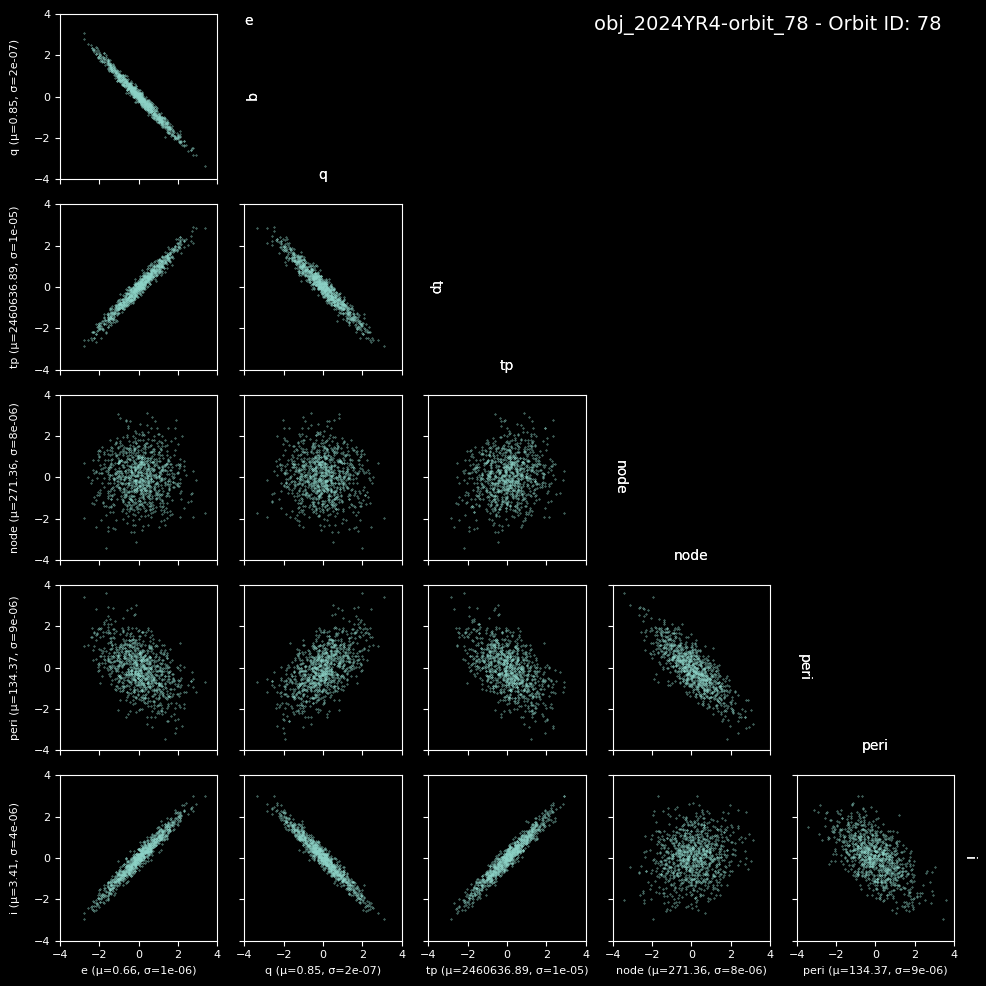

In [14]:
plt.style.use('dark_background')

propiedades = dict(
    e = dict(label='e', range=[-4, 4], unit=''),
    q = dict(label='q', range=[-4, 4], unit='AU'),
    tp = dict(label='tp', range=[-4, 4], unit='JD'),
    node = dict(label='node', range=[-4, 4], unit='deg'),
    peri = dict(label='peri', range=[-4, 4], unit='deg'),
    i = dict(label='i', range=[-4, 4], unit='deg'),
)
G = mn.MultiPlot(propiedades, figsize=2)
G.sample_scatter(sample_elements, s=0.1)

for i in range(5):
    G.axs[-1, i].set_xlabel(f"{propiedades[cov_label[i]]['label']} (μ={mus[i]:.2f}, σ={sigmas[i]:.0e})", fontsize=8)
    for j in range(i, 5):
        G.axs[j, 0].set_ylabel(f"{propiedades[cov_label[j + 1]]['label']} (μ={mus[j + 1]:.2f}, σ={sigmas[j + 1]:.0e})", fontsize=8)
G.fig.suptitle(f"{orbit_info['obj_suf']} - Orbit ID: {orbit_id}", fontsize=14, x=0.95, ha='right');

# G.fig.savefig(imgfile, dpi=300)